## Overview of Feature Labels and data distribution

This notebook given an overview of the used feature names and how they are combined into classes.
Also some infromations about the data distributions are shown.

In [1]:
# set the basepath
# read in the basis dataframe, withouth standardization
basepath="../"
## set the path
import sys
sys.path.append(basepath+"ppi.lib/")
import ml_lib as mlib
## start with all data:
(X, y, ftrnams, sampleids)=mlib.extract4ml()

## Grouping of Contact types, Amino acid types and secondary structure

The following tables describe the feature sets used for our analysis. 

### I. Interface Contact Types
This table defines the physical interaction types identified at the protein-protein interface during the MD simulation and calculated with GetContacts. 
The table shows the mapping of the different contact types into the groups (sb, pc, ps, ts, vdw, hb and wb).

In [3]:
# import pandas and read the .csv table which contains the feature names and the description of each feature
import pandas as pd

# Read CSV
ct_desc = pd.read_csv(basepath+"source/Contact_type_table.csv") #contact types
aa_type = pd.read_csv(basepath+"source/aa_type.csv", sep='\t') #amino acid types
ss_code = pd.read_csv(basepath+"source/ss_code.csv", sep='\t') #secondary structure types


# Set options to show ALL rows and columns
pd.set_option('display.max_rows', None)      # No limit on rows
pd.set_option('display.max_columns', None)   # No limit on columns
pd.set_option('display.max_colwidth', None)  # Don't cut long descriptions

# display the full table
display(ct_desc)

,Contact Type,Description,New Type
0,sb,Salt Bridge,sb
1,pc,Pi-Cation,pc
2,ps,Pi-Stacking,ps
3,ts,T-Stacking,ts
4,vdw,Van der Waals,vdw
5,hp,Hydrophobic Interactions,hb
6,hb,Hydrogen Bond (General),hb
7,hbbb,Backbone-Backbone Hydrogen Bond,hb
8,hbsb,Backbone-Sidechain Hydrogen Bond,hb
9,hbss,Sidechain-Sidechain Hydrogen Bond,hb


### II. Amino Acid Categorization
Amino acids are grouped into six functional categories (H, A, P, PC, NC, SC). 

In [4]:
display(aa_type)

,Category,Code,Amino Acids
0,Hydrophobic (Nonpolar),H,"ALA, VAL, LEU, ILE, MET, PRO"
1,Aromatic,A,"PHE, TYR, TRP"
2,Polar (Uncharged),P,"SER, THR, ASN, GLN, CYS"
3,Positively Charged,PC,"LYS, ARG, HIS"
4,Negatively Charged,NC,"ASP, GLU"
5,Special Cases,SC,"GLY (flexible), CYS (disulfide potential)"


### III. Secondary Structure Mapping (DSSP)
Using the DSSP algorithm, we mapped the 8 standard secondary structure states into a 3-state system: **H** (Helix), **S** (Strand), and **C** (Coil). The three categories are used for further analysis.

In [5]:
display(ss_code)

,Code,Category,Summary
0,H,α-helix,H
1,B,residue in isolated β-bridge,C
2,E,"extended strand, participates in β ladder",S
3,G,3-helix (310 helix),H
4,I,5 helix (π-helix),H
5,T,hydrogen bonded turn,C
6,S,bend,C
7,C,Coil,C


### Feature names and descriptions of each feature
This table shows the Feature names which are used in the analysis. Also the description for each feature is given in the table.

In [7]:
# import pandas and read the .csv table which contains the feature names and the description of each feature
import pandas as pd

# Read CSV
feature_desc = pd.read_csv(basepath+"source/feature_names_description.csv")

# Set options to show ALL rows and columns
pd.set_option('display.max_rows', None)      # No limit on rows
pd.set_option('display.max_columns', None)   # No limit on columns
pd.set_option('display.max_colwidth', None)  # Don't cut long descriptions

# display the full table
feature_desc

,Features,Description
0,AFDisord,AlphaFold disorder fraction
1,ContDens,Contact denstiy
2,countHB,Hydrogen bond count
3,countPC,Pi-Cation count
4,countPS,Pi-stacking count
5,countSB,Salt bridge count
6,countTS,T-stacking count
7,countVdW,Van der Waals count
8,countWB,Water bridge count
9,ElecMean,Mean electrostatic energy


#### Distributions of the dataframe

In [8]:
# the total number of samples and the presence of transmembrane status in Protein B is presented by the code
import pandas as pd

# Convert labels to a Series for easy counting
y_series = pd.Series(y, name='Label')

# Total samples
total = len(y_series)

# Count occurrences per label value
counts = y_series.value_counts().sort_index()
percentages = (counts / total * 100).round(1)

# Display summary
summary_df = pd.DataFrame({
    'Class': ['non-TM' if lbl == 0 else 'TM' if lbl == 1 else lbl for lbl in counts.index],
    'Label Value': counts.index,
    'Count': counts.values,
    'Percentage': percentages.values.astype(str) + '%'
})
summary_df

# we can also present it easier
# pd.Series(y).value_counts()

,Class,Label Value,Count,Percentage
0,non-TM,False,1014,49.7%
1,TM,True,1028,50.3%


The data frame contains 2042 PPIs. Transmembrane status of Protein B is True for 50.3 % of the samples, which are 1028 PPIs. The others are no transmembrane for Protein B. Protein A is a SLC therefore always in the transmembrane.

#### Lower dimensional space of the input features colored by the Transmembrane label of Protein B
The lower dimensional plot shows that the PPIs are seperated into transmembrane and non transmembrane in this space.

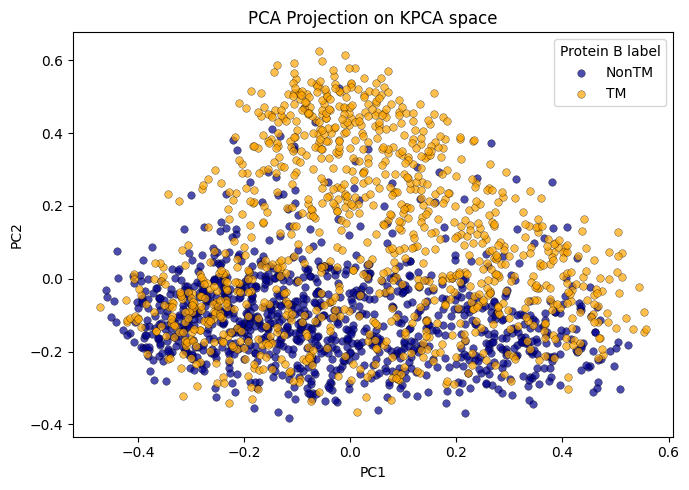

In [9]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KPCA transform the data
kpca = KernelPCA(n_components=10, kernel='rbf')
X_kpca = kpca.fit_transform(X_scaled)

# PCA on kpca space
pca = PCA(n_components=2)
X_final = pca.fit_transform(X_kpca)

# Plot the lower dimensional space colored by transmembrane label of Protein B
fig, ax = plt.subplots(figsize=(7, 5))

classes = np.unique(y)
colors = ['darkblue', 'orange']
labels = ['NonTM', 'TM'] 

for cls, color, label in zip(classes, colors, labels):
    mask = y == cls
    ax.scatter(X_final[mask, 0], X_final[mask, 1],
               c=color, s=30, alpha=0.7,
               edgecolor='k', linewidth=0.3,
               label=label)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA Projection on KPCA space")
ax.legend(title="Protein B label", framealpha=0.8)
plt.tight_layout()
plt.show()

In [10]:
# read in the untransformed data to visualize the true distributions for an overview
(X, y, ftrnams, sampleids) = mlib.extract4ml(fname=basepath+"source/agg_final.csv")
#ftrnams

In [11]:
# Create DataFrame and display the distribution in the dataframe per feature (overall, no transformations)
df = pd.DataFrame(X, columns=ftrnams)
df['Transmembrane'] = y
(df[ftrnams].describe().T).round(3)

,count,mean,std,min,25%,50%,75%,max
MD_MMGBSA_VdW_mean,2042.0,-0.568,0.163,-1.181,-0.671,-0.570,-0.469,-0.044
MD_MMGBSA_Elec_mean,2042.0,-2.375,3.331,-34.388,-3.606,-1.870,-0.571,13.112
MD_MMGBSA_PolarSolv_mean,2042.0,2.693,3.281,-12.755,0.903,2.192,3.919,34.131
MD_MMGBSA_NonPolarSolv_mean,2042.0,-0.100,0.022,-0.193,-0.114,-0.101,-0.087,-0.015
MD_RMSF_mean,2042.0,2.038,0.755,0.707,1.485,1.913,2.460,6.434
Coords_RMSD_from_Centroid_CA,2042.0,20.520,6.294,8.815,16.137,19.075,23.639,55.996
Prop_ResCode_ALA,2042.0,0.073,0.024,0.011,0.056,0.071,0.088,0.214
Prop_ResCode_ARG,2042.0,0.070,0.028,0.013,0.051,0.067,0.086,0.250
Prop_ResCode_ASN,2042.0,0.047,0.021,0.008,0.033,0.043,0.057,0.193
Prop_ResCode_ASP,2042.0,0.055,0.023,0.009,0.038,0.053,0.069,0.179


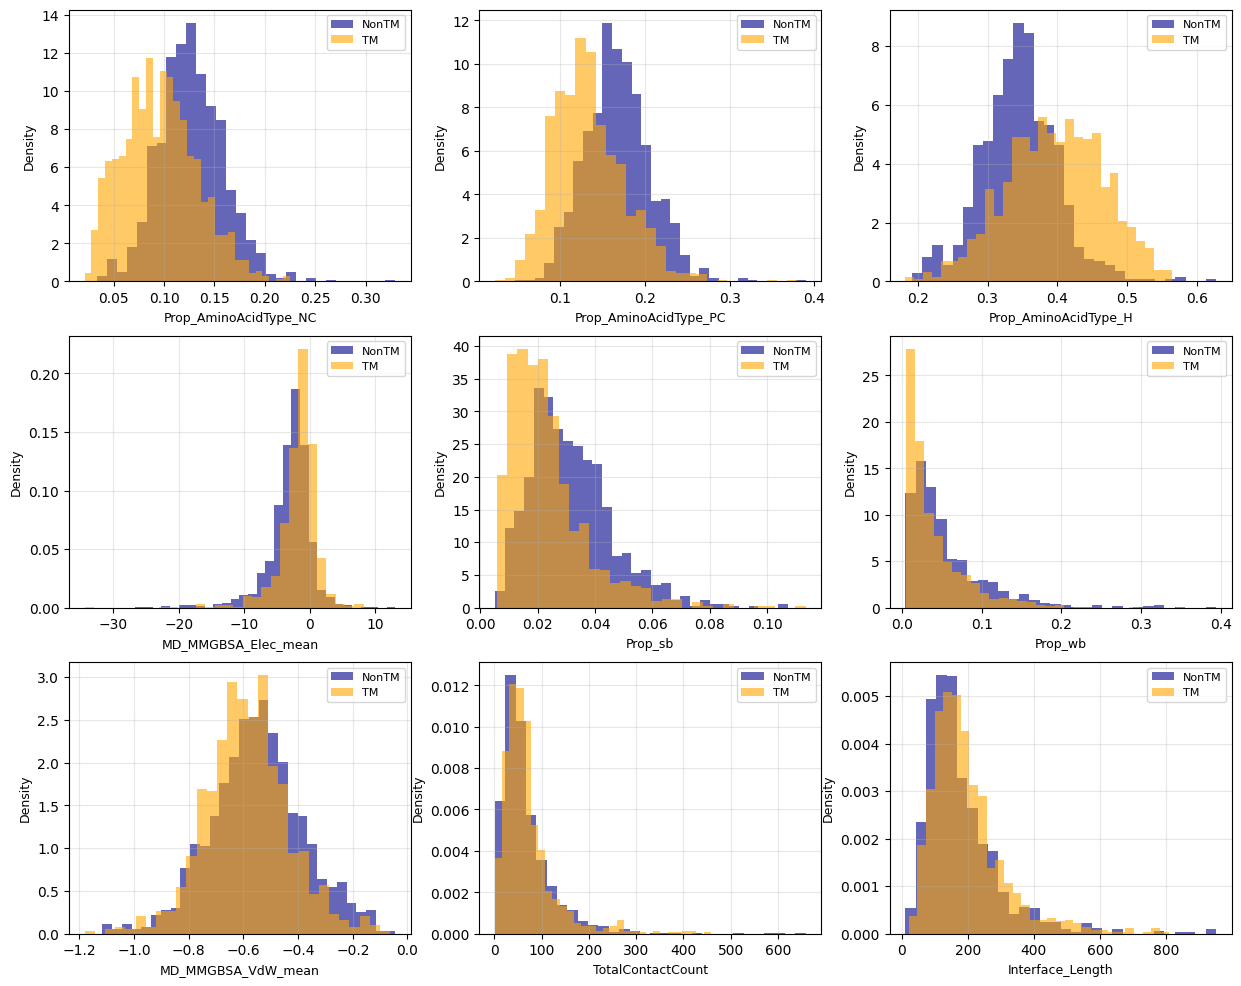

In [12]:
# Plot some example features to visualize the distribution of the two classes (TM and NonTM of Protein B)
features_to_plot = [
    'Prop_AminoAcidType_NC',
    'Prop_AminoAcidType_PC', 
    'Prop_AminoAcidType_H',
    'MD_MMGBSA_Elec_mean',
    'Prop_sb',
    'Prop_wb',
    'MD_MMGBSA_VdW_mean',
    'TotalContactCount',
    'Interface_Length'
]
# Create plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, feature in enumerate(features_to_plot):
    # Histogram for each class
    axes[i].hist(df[df['Transmembrane']==0][feature], bins=30, alpha=0.6, 
                label='NonTM', color='darkblue', density=True)
    axes[i].hist(df[df['Transmembrane']==1][feature], bins=30, alpha=0.6, 
                label='TM', color='orange', density=True)
    
    axes[i].set_xlabel(feature, fontsize=9)
    axes[i].set_ylabel('Density', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)